In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D  
import figurefirst as fifi
import seaborn as sns
###
import sys
sys.path.insert(1, '../../../Code')
from PlotUtilities import *
from FeatureFunctions import *



from tsfresh import defaults, extract_features
from tsfresh.feature_selection.relevance import calculate_relevance_table
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import MinimalFCParameters #
 
import umap


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


# Set params and load FiFi template

In [2]:
plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']
plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'


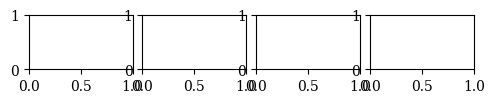

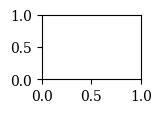

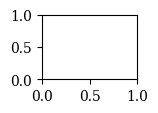

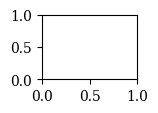

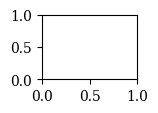

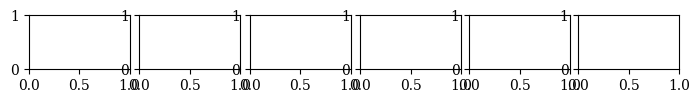

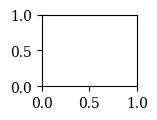

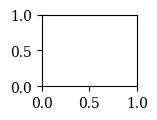

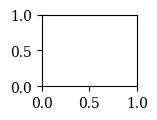

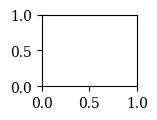

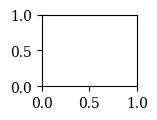

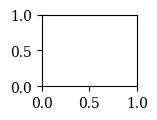

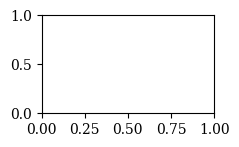

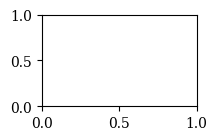

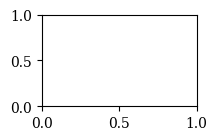

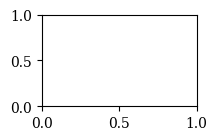

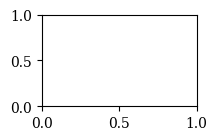

In [62]:
layout = fifi.svg_to_axes.FigureLayout('../f6_realvssim_v3.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])



# Laminar - Control

In [4]:
lam_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/training_laminar_df.hdf')



In [5]:
lam_df = get_normed_positions(lam_df)

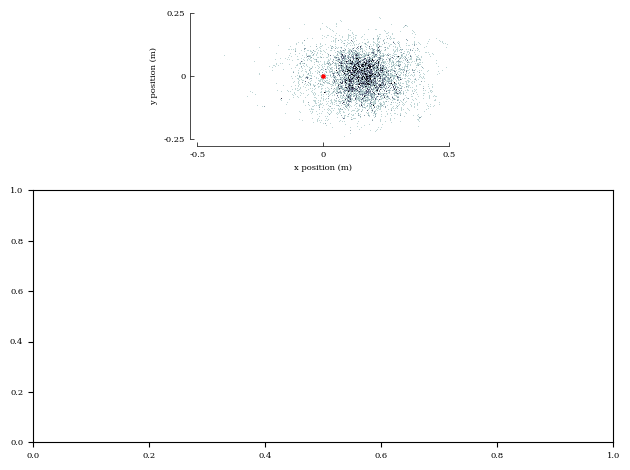

In [63]:
df1_left = lam_df.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
#ax[0] = layout.axes[('A1', 'a1')]
ax[1] = layout.axes[('A1', 'a2')]




a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[0].scatter(0,0, color='red', s=5)

a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)



fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':5, 'bottom':5},   tick_length=3, linewidth=.5)
fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':5}, tick_length=3, linewidth=.5)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

ax[0].set_xlabel('x position (m)')
ax[0].set_ylabel('y position (m)')

ax[1].set_xlabel('x velocity (m/s)')
ax[1].set_ylabel('y velocity (m/s)')
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

ax[0].set_xticklabels(['-0.5', '0','0.5'])
ax[0].set_yticklabels(['-0.25', '0','0.25'])

ax[1].set_xticklabels(['-1','', '0','', '1'])
ax[1].set_yticklabels(['-1','', '0','', '1'])
ax[1].text(x=.8,y=0.9, s= 'n=' + str(len(dfl100_void.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['A1'], 'A1', cleartarget=True)

In [7]:
layout.write_svg('test.svg')

# Casting Simulations

In [8]:
casting_sims=pd.read_hdf('../../../Data/Simulated_Trajectory_Data/casting_sim_constwind_n1000.hdf')

In [9]:
casting_sims['ground speed']= np.sqrt(casting_sims.xvel**2 + casting_sims.yvel**2)

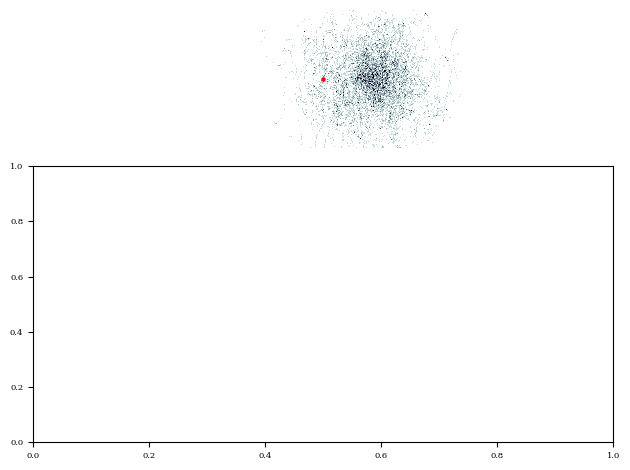

In [64]:
df1_left = casting_sims.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
#ax[0] = layout.axes[('B1', 'b1')]
ax[1] = layout.axes[('B1', 'b2')]

np.random.seed(1000)
dfl100_void = dfl100_void[dfl100_void.obj_id_unique.isin(np.random.choice(df1_left.obj_id_unique.unique(),300,replace=False))]



a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[0].scatter(0,0, color='red', s=5)





#df1_left = flash_low_bottom_on.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
#dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]

a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)



#fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':8, 'bottom':15},   tick_length=3, linewidth=.5)
#fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':-5}, tick_length=3, linewidth=.5)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

#ax[0].set_xlabel('x position (m)')
#ax[0].set_ylabel('y position (m)')

#ax[1].set_xlabel('x velocity (m/s)')
#ax[1].set_ylabel('y velocity (m/s)')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

ax[0].axis('off')
ax[1].axis('off')
ax[1].text(x=.8,y=0.9, s= 'n=' + str(len(dfl100_void.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['B1'], 'B1', cleartarget=True)


# Circling Simulations

In [11]:
circle_sims=pd.read_hdf('../../../Data/Simulated_Trajectory_Data/SimulatedData/circle_sim_nowind_n1000.hdf')

In [12]:
circle_sims['ground speed'] = np.sqrt(circle_sims.xvel**2  + circle_sims.yvel**2)

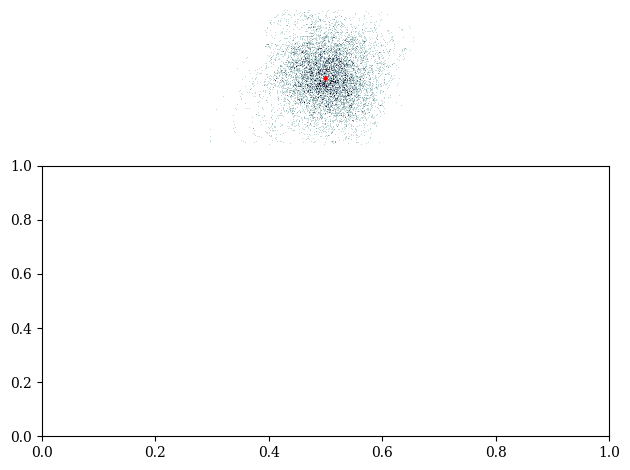

In [65]:
df1_left = circle_sims.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]
np.random.seed(1000)
dfl100_void = dfl100_void[dfl100_void.obj_id_unique.isin(np.random.choice(df1_left.obj_id_unique.unique(),300,replace=False))]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
#ax[0] = layout.axes[('C1', 'c1')]
ax[1] = layout.axes[('C1', 'c2')]


a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[0].scatter(0,0, color='red', s=5)

a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)


ax[0].axis('off')
ax[1].axis('off')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[1].text(x=.8,y=0.9, s= 'n=' + str(len(dfl100_void.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['C1'], 'C1', cleartarget=True)



# Still air

In [14]:
nw_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/training_nw_df.hdf')



In [15]:
nw_df = get_normed_positions(nw_df)

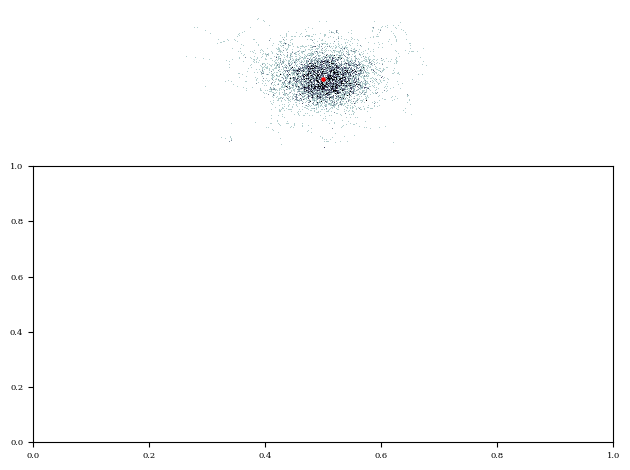

In [66]:
df1_left = nw_df.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
#ax[0] = layout.axes[('D1', 'd1')]
ax[1] = layout.axes[('D1', 'd2')]




a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[0].scatter(0,0, color='red', s=5)


a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)


ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

ax[0].axis('off')
ax[1].axis('off')
ax[1].text(x=.8,y=0.9, s= 'n=' + str(len(dfl100_void.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['D1'], 'D1', cleartarget=True)



# Steady, low

In [17]:
bottom_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_bottom_laminar_09092024.hdf')


In [18]:
bottom_on_df['ground speed']= np.sqrt(bottom_on_df.xvel**2 + bottom_on_df.yvel**2)

In [19]:
df_flash_bottom_on = bottom_on_df[bottom_on_df.duration>0]
df_sham_bottom_on =bottom_on_df[bottom_on_df.duration==0]


In [20]:
flash_low_bottom_on = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_bottom_on  = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

sham_low_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

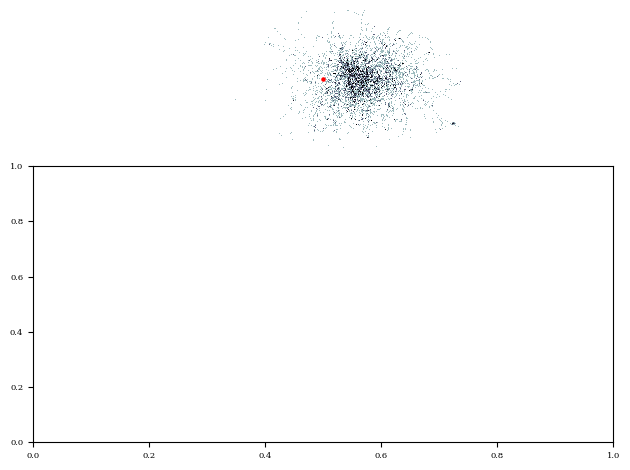

In [67]:
df1_left = flash_low_bottom_on.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
#ax[0] = layout.axes[('A2', 'a3')]
ax[1] = layout.axes[('A2', 'a4')]




a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[0].scatter(0,0, color='red', s=5)



a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)



fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':5}, tick_length=3, linewidth=.5)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)



ax[1].set_xlabel('x velocity (m/s)')
ax[1].set_ylabel('y velocity (m/s)')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')


ax[1].set_xticklabels(['-1','', '0','', '1'])
ax[1].set_yticklabels(['-1','', '0','', '1'])

ax[0].axis('off')

ax[1].text(x=.8,y=0.9, s= 'n=' + str(len(dfl100_void.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['A2'], 'A2', cleartarget=True)


# Unsteady, low

In [22]:
top_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_top_laminar_09092024.hdf')

In [23]:
top_on_df['ground speed'] = np.sqrt(top_on_df['xvel']**2 + top_on_df['yvel']**2)

In [24]:
df_flash_top_on = top_on_df[top_on_df.duration>0]
df_sham_top_on =top_on_df[top_on_df.duration==0]

In [25]:
flash_low_top_on = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_top_on  = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)


sham_low_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

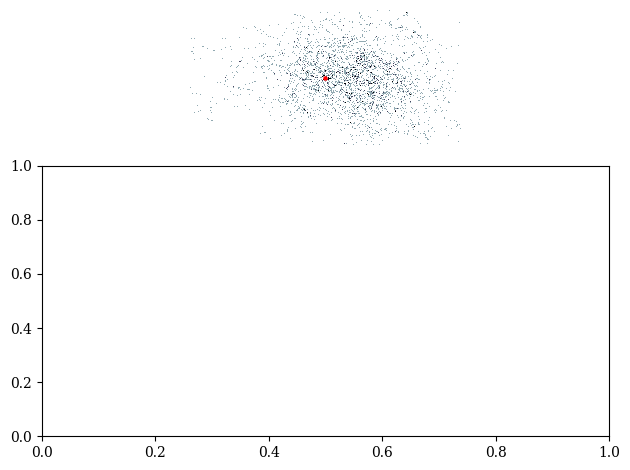

In [68]:
df1_left = flash_low_top_on.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
#ax[0] = layout.axes[('E2', 'e3')]
ax[1] = layout.axes[('E2', 'e4')]




a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0,vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[0].scatter(0,0, color='red', s=5)



a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0,vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)

ax[0].axis('off')
ax[1].axis('off')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[1].text(x=.8,y=0.9, s= 'n=' + str(len(dfl100_void.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['E2'], 'E2', cleartarget=True)



# Casting sims in CFD

In [27]:
casting_sims_cfd = pd.read_hdf('../../../Data/Simulated_Trajectory_Data/cfd_sim_results_merged_casting_2025-01-07.hdf')

In [28]:
unsteady_casting = casting_sims_cfd.groupby('obj_id_unique').filter(lambda d: d.z.max()<.25).reset_index(drop=True)
steady_casting = casting_sims_cfd.groupby('obj_id_unique').filter(lambda d: d.z.min()>.25).reset_index(drop=True)


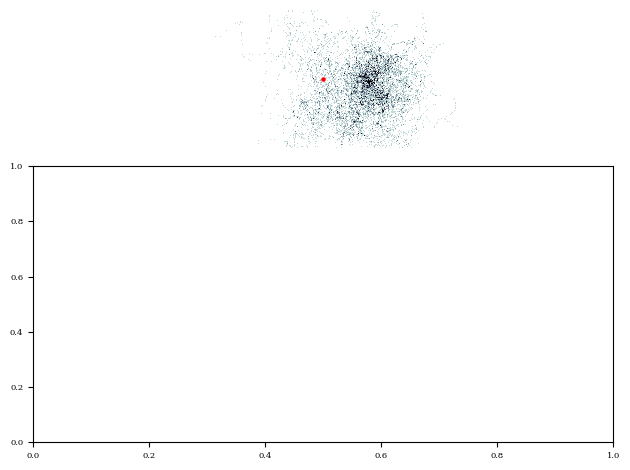

In [69]:
df1_left = steady_casting.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]
np.random.seed(1000)
dfl100_void = dfl100_void[dfl100_void.obj_id_unique.isin(np.random.choice(df1_left.obj_id_unique.unique(),300,replace=False))]

fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
#ax[0] = layout.axes[('B2', 'b3')]
ax[1] = layout.axes[('B2', 'b4')]




a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0,vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[0].scatter(0,0, color='red', s=5)


a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)



#fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':8, 'bottom':15},   tick_length=3, linewidth=.5)
#fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':-5}, tick_length=3, linewidth=.5)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

#ax[0].set_xlabel('x position (m)')
#ax[0].set_ylabel('y position (m)')

#ax[1].set_xlabel('x velocity (m/s)')
#ax[1].set_ylabel('y velocity (m/s)')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

ax[0].axis('off')
ax[1].axis('off')

ax[1].text(x=.8,y=0.9, s= 'n=' + str(len(dfl100_void.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['B2'], 'B2', cleartarget=True)


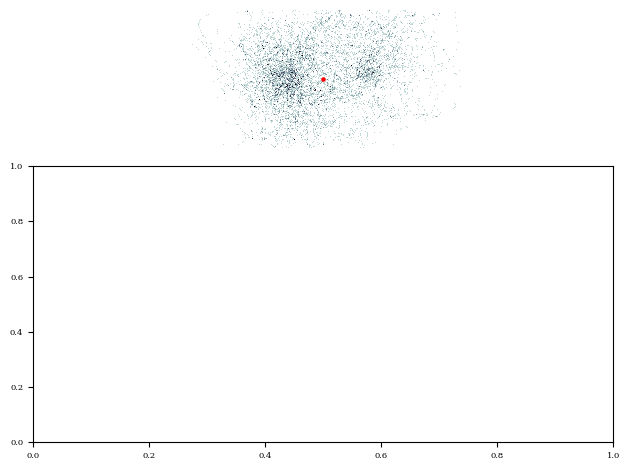

In [70]:
df1_left = unsteady_casting.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]
np.random.seed(1000)
dfl100_void = dfl100_void[dfl100_void.obj_id_unique.isin(np.random.choice(dfl100_void.obj_id_unique.unique(),300,replace=False))]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
#ax[0] = layout.axes[('D2', 'd3')]
ax[1] = layout.axes[('D2', 'd4')]




a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0,vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[0].scatter(0,0, color='red', s=5)





#df1_left = flash_low_bottom_on.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
#dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]

a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)



#fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':8, 'bottom':15},   tick_length=3, linewidth=.5)
#fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':-5}, tick_length=3, linewidth=.5)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

#ax[0].set_xlabel('x position (m)')
#ax[0].set_ylabel('y position (m)')

#ax[1].set_xlabel('x velocity (m/s)')
#ax[1].set_ylabel('y velocity (m/s)')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

ax[0].axis('off')
ax[1].axis('off')

ax[1].text(x=.8,y=0.9, s= 'n=' + str(len(dfl100_void.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)


layout.append_figure_to_layer(layout.figures['D2'], 'D2', cleartarget=True)


# Circle Sims in CFD

In [31]:
circle_sims_cfd = pd.read_hdf('../../../Data/Simulated_Trajectory_Data/cfd_sim_results_merged_circling_2025-01-07.hdf')

In [32]:
unsteady_circle = circle_sims_cfd.groupby('obj_id_unique').filter(lambda d: d.z.max()<.25).reset_index(drop=True)
steady_circle = circle_sims_cfd.groupby('obj_id_unique').filter(lambda d: d.z.min()>.25).reset_index(drop=True)


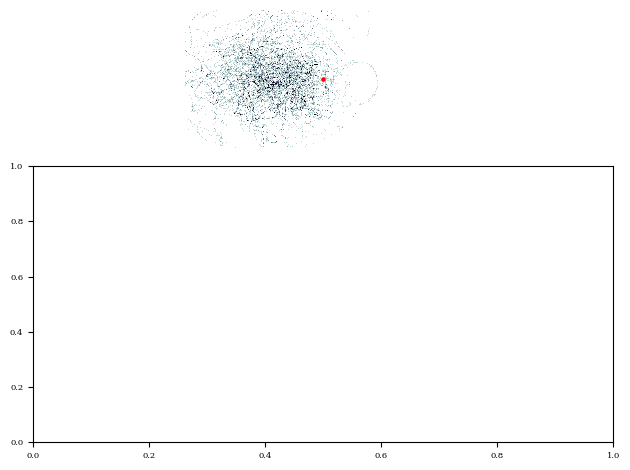

In [71]:
df1_left = steady_circle.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]
np.random.seed(1000)
dfl100_void = dfl100_void[dfl100_void.obj_id_unique.isin(np.random.choice(dfl100_void.obj_id_unique.unique(),300,replace=False))]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
#ax[0] = layout.axes[('C2', 'c3')]
ax[1] = layout.axes[('C2', 'c4')]




a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[0].scatter(0,0, color='red', s=5)





#df1_left = flash_low_bottom_on.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
#dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]

a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)



#fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':8, 'bottom':15},   tick_length=3, linewidth=.5)
#fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':-5}, tick_length=3, linewidth=.5)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

#ax[0].set_xlabel('x position (m)')
#ax[0].set_ylabel('y position (m)')

#ax[1].set_xlabel('x velocity (m/s)')
#ax[1].set_ylabel('y velocity (m/s)')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

ax[0].axis('off')
ax[1].axis('off')
ax[1].text(x=.8,y=0.9, s= 'n=' + str(len(dfl100_void.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['C2'], 'C2', cleartarget=True)


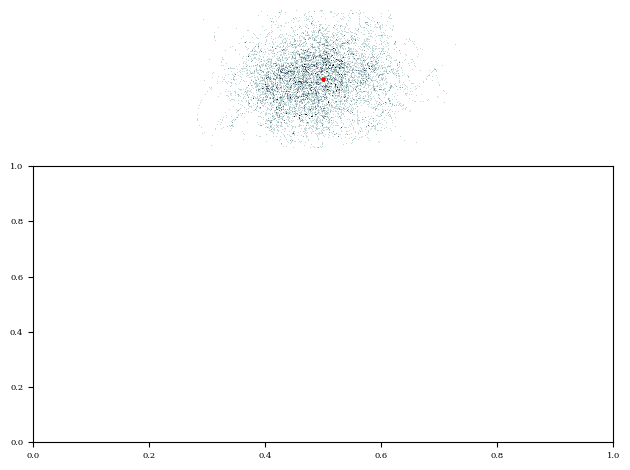

In [72]:
df1_left = unsteady_circle.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]
np.random.seed(1000)
dfl100_void = dfl100_void[dfl100_void.obj_id_unique.isin(np.random.choice(dfl100_void.obj_id_unique.unique(),300,replace=False))]


fig,ax = plt.subplots( nrows=2, gridspec_kw={'height_ratios': [1, 2]}, layout='tight')
#ax[0] = layout.axes[('E1', 'e1')]
ax[1] = layout.axes[('E1', 'e2')]




a = np.linspace(-.5, .5, 500)
b = np.linspace(-.25, .25, 500)
x = np.linspace(-.5, .5, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-.25, .25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['normed_x_680'],dfl100_void['normed_y_680'],  bins =(x, y))
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
sumz = newdf.sum(axis=0)
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[0].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[0].scatter(0,0, color='red', s=5)





#df1_left = flash_low_bottom_on.groupby("obj_id_unique").filter(lambda d: d['ground speed'].mean()>.15)
#dfl100_void = df1_left[df1_left['time stamp'].between(1100,3000)]

a = np.linspace(-1.25, 1.25, 500)
b = np.linspace(-1.25, 1.25, 500)
x = np.linspace(-1.25, 1.25, 501) #np.arange(-0.5,0.5, .0025)
y = np.linspace(-1.25, 1.25, 501)
bin_values,_,__ = np.histogram2d(dfl100_void['xvel'],dfl100_void['yvel'],  bins =(x, y))
#print(bin_values)
newdf = pd.DataFrame(bin_values.T, columns=a, index=b)
#print(newdf)
sumz = newdf.sum(axis=0)
#print(sumz)
#ax.set_title("Laminar Wind: Flash")
newdf_normed= newdf
for i in range(0,len(sumz)):
    newdf_normed.iloc[:,i] = newdf.iloc[:,i]/len(dfl100_void)
X,Y = np.meshgrid(x,y)
# Plot the heatmap
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0,vmax=0.0001, cmap='bone_r', shading='flat', rasterized=True)
ax[1].scatter(0,0, color='red', s=5)



#fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,.25], xticks=[-.5,0,.5], spine_locations={'left':8, 'bottom':15},   tick_length=3, linewidth=.5)
#fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-1,-.5,0,.5,1], xticks=[-1,-.5,0,.5,1], spine_locations={'left':5, 'bottom':-5}, tick_length=3, linewidth=.5)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

#ax[0].set_xlabel('x position (m)')
#ax[0].set_ylabel('y position (m)')

#ax[1].set_xlabel('x velocity (m/s)')
#ax[1].set_ylabel('y velocity (m/s)')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

ax[0].axis('off')
ax[1].axis('off')
ax[1].text(x=.8,y=0.9, s= 'n=' + str(len(dfl100_void.obj_id_unique.unique())), fontsize=5,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7),zorder=1)

layout.append_figure_to_layer(layout.figures['E1'], 'E1', cleartarget=True)


# Trajectories

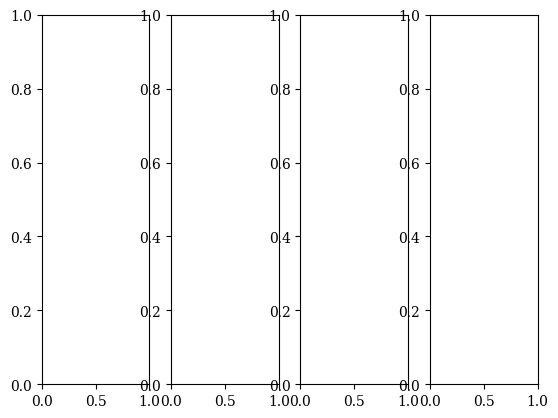

In [73]:
trajs= ['687_20220927_170437', '2025-01-07_cast_and_surge_constantwind_236', '2025-01-11_sink_and_circle_constantwind_194', '2088_20220815_162329'] 
fig, ax= plt.subplots(ncols=4)
ax[0] = layout.axes[('T1', 't1')]
ax[1] = layout.axes[('T1', 't2')]
ax[2] = layout.axes[('T1', 't3')]
ax[3] = layout.axes[('T1', 't4')]

for i, df in enumerate([lam_df, casting_sims,circle_sims, nw_df]):
    get_subplot(df, trajs[i], ax=ax[i])


layout.append_figure_to_layer(layout.figures['T1'], 'T1', cleartarget=True)

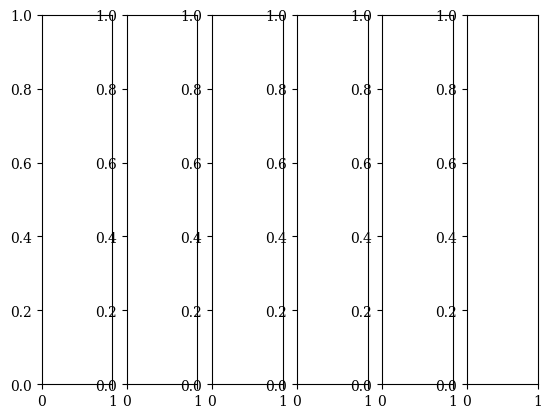

In [74]:
trajs= ['27980_20240114_171954','2025-01-03_cast_and_surge_vel_2_4', '2025-01-06_sink_and_circle_vel_1_192', '2025-01-03_cast_and_surge_vel_1_661','2025-01-06_sink_and_circle_vel_1_111' ,'8802_20240514_172126']
fig, ax= plt.subplots(ncols=6)


ax[0] = layout.axes[('T2', 't5')]
ax[1] = layout.axes[('T2', 't6')]
ax[2] = layout.axes[('T2', 't7')]
ax[3] = layout.axes[('T2', 't8')]
ax[4] = layout.axes[('T2', 't9')]
ax[5] = layout.axes[('T2', 't10')]
for i, df in enumerate([flash_low_bottom_on,steady_casting, steady_circle,unsteady_casting,unsteady_circle  , flash_low_top_on]):
    get_subplot(df, trajs[i], ax=ax[i])


layout.append_figure_to_layer(layout.figures['T2'], 'T2', cleartarget=True)

# Features; UMAP

In [76]:

np.random.seed(1000)
dfs = [lam_df,
    nw_df,
      casting_sims[casting_sims.obj_id_unique.isin(np.random.choice(casting_sims.obj_id_unique.unique(),300,replace=False))],
      circle_sims[circle_sims.obj_id_unique.isin(np.random.choice(circle_sims.obj_id_unique.unique(),300,replace=False))],
    
       flash_low_bottom_on, 
       flash_low_top_on,
       flash_up_top_on, 
       flash_up_bottom_on, 
      
      
       unsteady_casting[unsteady_casting.obj_id_unique.isin(np.random.choice(unsteady_casting.obj_id_unique.unique(),300,replace=False))],
      steady_casting[steady_casting.obj_id_unique.isin(np.random.choice(steady_casting.obj_id_unique.unique(),300,replace=False))],
      unsteady_circle[unsteady_circle.obj_id_unique.isin(np.random.choice(unsteady_circle.obj_id_unique.unique(),300,replace=False))],
      steady_circle[steady_circle.obj_id_unique.isin(np.random.choice(steady_circle.obj_id_unique.unique(),300,replace=False))],]


In [77]:
dfs = calculate_features(dfs, start_time=1100)

df # 0
Culled 6 trajectories
n trajs: 312
df # 1
Culled 1 trajectories
n trajs: 251
df # 2
Culled 0 trajectories
n trajs: 300
df # 3
Culled 1 trajectories
n trajs: 300
df # 4
Culled 45 trajectories
n trajs: 255
df # 5
Culled 88 trajectories
n trajs: 231
df # 6
Culled 20 trajectories
n trajs: 115
df # 7
Culled 7 trajectories
n trajs: 99
df # 8
Culled 0 trajectories
n trajs: 300
df # 9
Culled 0 trajectories
n trajs: 300
df # 10
Culled 3 trajectories
n trajs: 300
df # 11
Culled 2 trajectories
n trajs: 300


In [78]:
all_dfs = pd.concat(dfs)

In [79]:
X = extract_features(all_dfs[['xvel','yvel', 'normed_x_680', 'normed_y_680','obj_id_unique','time stamp']].dropna(), 
                         column_id='obj_id_unique', column_sort='time stamp',
                         #default_fc_parameters=ComprehensiveFCParameters(),
                         default_fc_parameters=MinimalFCParameters(),
                     impute_function=impute)

# these are just the length of each time series, not relevant features
X = X.drop(columns=['xvel__length','yvel__length','normed_x_680__length','normed_y_680__length'])


2025-02-05 11:30:54,757 [WARNING] Dependency not available for matrix_profile, this feature will be disabled!
Feature Extraction: 100%|██████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 25.04it/s]


In [80]:
cmap_sim = plt.get_cmap('BrBG', 16) 
cmap_real = plt.get_cmap('RdBu', 16) 


#  Steady: real -> Blues; sim -> green
# Unsteady: real -> orange; sim -> pink/brown
'''
df_colors = [cmap_real(3),
             cmap_real(14),
            cmap_sim(2),
             cmap_sim(14),
             
             'darkorange',
            cmap_real(13),
             cmap_real(4),
            cmap_real(12),
            
             cmap_sim(13),
            cmap_sim(3),
             cmap_sim(12),
            cmap_sim(4),]

'''


df_colors = [cmap_real(1),
             cmap_real(15),
            cmap_sim(2),
             cmap_sim(14),
             
             'darkorange',
            cmap_real(13),
             cmap_real(4),
            cmap_real(12),
            
             cmap_sim(13),
            cmap_sim(3),
             cmap_sim(12),
            cmap_sim(4),]



'''
df_colors = [cmap_real(1),
             cmap_real(15),

             'darkorange',
            cmap_real(13),
             cmap_real(3),#cmap_real(6),
            cmap_real(11),]
'''



df_labels = ['Laminar', #0
             'Still Air', #1
            'Casting Sim', #2
            'Circling Sim', #3 
            
             
             'Steady, z < 0.25m', #4
             'Unsteady, z < 0.25m', #5
             'Steady, z > 0.25m', #6
             'Unsteady, z > 0.25m', #7
           
             
      'Casting Sim, Unsteady', #8
      'Casting Sim, Steady', #9
      'Circling Sim, Unsteady', #10
      'Circling Sim, Steady',] #11


df_features_list = []



feature_names = ['circle_cross', 
                 'hull_area', 
                 'hull_roundness', 

                 'heading_derivative_absmean',
                 'heading_difference_sliding_absmean',]


for i, df in enumerate(dfs):
    df['dataset_name'] = df_labels[i]
    
    #df =df.assign(color=df.apply(lambda x: df_colors[i], 1))
    df_features = df.groupby('obj_id_unique')['dataset_name'].first()
    
    
    for feature_name in feature_names:
        df_tmp = np.abs( df.groupby('obj_id_unique')[feature_name].mean() )
        df_features = pd.concat([df_features, df_tmp], axis=1)
    df_features['class']=i
    df_features =df_features.assign(color=df_features.apply(lambda x: df_colors[i], 1))
    df_features_list.append(df_features)
    
df_features = pd.concat(df_features_list)

In [81]:
dfs_important_feats = df_features.join(X)

In [82]:
training_data = dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])].drop(columns=['dataset_name', 'color','class',])#+ irrel_mann)#+ irrel_feats)
y_classes =  dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])]['class'] 
df_pvalues_mann = calculate_relevance_table(training_data,y_classes, fdr_level=0.05, hypotheses_independent=False)
irrel_feats_mannu=list(df_pvalues_mann [df_pvalues_mann['p_value']>0.05].feature.values)

# Import Model Trained on Lam + Still Air Data

In [83]:
import pickle
f_name = '../../../Data/UMAP_trained.sav'
trained_model = pickle.load((open(f_name, 'rb')))
print(type(trained_model))


<class 'umap.umap_.UMAP'>


In [84]:
training_data = dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])].sort_index().drop(columns=['dataset_name', 'color','class', ] + irrel_feats_mannu)
training_data  =StandardScaler().fit_transform(training_data.values)
y_classes =  dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])]['class'].sort_index() 
y_colors =  dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])]['color'].sort_index() 



X_test = dfs_important_feats[dfs_important_feats.dataset_name.isin(['Casting Sim', 'Circling Sim' ])].sort_index().drop(columns=['dataset_name', 'color','class', ]  + irrel_feats_mannu)
X_test  =StandardScaler().fit_transform(X_test.values)

y_test =  dfs_important_feats[dfs_important_feats.dataset_name.isin(['Casting Sim', 'Circling Sim'])]['color'].sort_index()

test_embedding = trained_model.transform(X_test)


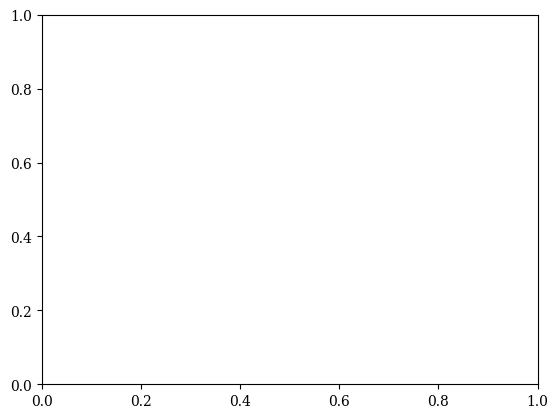

In [85]:
plottingdf = dfs_important_feats[dfs_important_feats.dataset_name.isin([ 'Casting Sim', 'Circling Sim' ])].sort_index().copy()#.drop(columns=['dataset_name', 'color','class', ]+ irrel_feats+irrel_feats_lam).copy()
plottingdf['embedding_x'] = test_embedding[:, 0]
plottingdf['embedding_y'] =test_embedding[:, 1]



fig, ax = plt.subplots()

ax = layout.axes[('G1', 'g1')]
sns.kdeplot(x=trained_model.embedding_[:, 0], y=trained_model.embedding_[:, 1], hue=y_colors, levels=3, thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

legend_labels = []

for i in plottingdf['dataset_name'].unique():
    ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color, marker='d')
    legend_labels.append(Line2D([0], [0],marker='d', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))

 
ax.set_xlim(1,13)
ax.set_ylim(7,13)
ax.set_aspect('equal')


#ax.legend(loc='upper left', handles=legend_labels)# orange_patch, yellow_patch, blue_patch, cyan_patch,black_patch],)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.axis('off')
layout.append_figure_to_layer(layout.figures['G1'], 'G1', cleartarget=True)


In [86]:
X_test = dfs_important_feats[dfs_important_feats.dataset_name.isin(['Steady, z < 0.25m', 'Unsteady, z < 0.25m', ])].sort_index().drop(columns=['dataset_name', 'color','class', ] + irrel_feats_mannu)#+ irrel_feats+irrel_feats_lam)
X_test  =StandardScaler().fit_transform(X_test.values)

y_test =  dfs_important_feats[dfs_important_feats.dataset_name.isin([ 'Steady, z < 0.25m', 'Unsteady, z < 0.25m',])]['color'].sort_index() 

test_embedding = trained_model.transform(X_test)

X_test = dfs_important_feats[dfs_important_feats.dataset_name.isin([
       'Circling Sim, Steady', 'Casting Sim, Unsteady', 'Circling Sim, Unsteady', 'Casting Sim, Steady', 
       ])].drop(columns=['dataset_name', 'color','class', ] + irrel_feats_mannu).sort_index()# + irrel_feats +irrel_feats_lam)
X_test  =StandardScaler().fit_transform(X_test.values)

y_test1 =  dfs_important_feats[dfs_important_feats.dataset_name.isin([
       'Circling Sim, Steady', 'Casting Sim, Unsteady', 'Circling Sim, Unsteady', 'Casting Sim, Steady', 
       ])]['color'].sort_index()


test_embedding1 = trained_model.transform(X_test)


In [87]:
plottingdf = dfs_important_feats[dfs_important_feats.dataset_name.isin([
       'Circling Sim, Steady', 'Casting Sim, Unsteady', 'Circling Sim, Unsteady', 'Casting Sim, Steady',
      ])].sort_index().copy()#.drop(columns=['dataset_name', 'color','class', ]+ irrel_feats+irrel_feats_lam).copy()
plottingdf['embedding_x'] = test_embedding1[:, 0]
plottingdf['embedding_y'] =test_embedding1[:, 1]

#.groupby('dataset_name').sample(400, random_state=100).

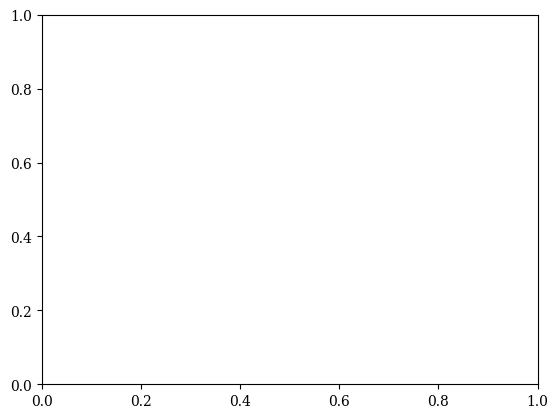

In [88]:


fig, ax = plt.subplots()

ax = layout.axes[('Z1', 'z1')]
sns.kdeplot(x=test_embedding[:, 0], y=test_embedding[:, 1], hue=y_test, levels=3,  thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

legend_labels = []

for i in ['Casting Sim, Steady', ]:

    if "Casting" in plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color, marker='d')
        legend_labels.append(Line2D([0], [0],marker='d', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))
    if "Circling" in plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color)
        legend_labels.append(Line2D([0], [0],marker='.', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))
    
  
    
ax.set_xlim(1,13)
ax.set_ylim(7,13)
ax.set_aspect('equal')


#ax.legend( handles=legend_labels)# orange_patch, yellow_patch, blue_patch, cyan_patch,black_patch],)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.axis('off')


layout.append_figure_to_layer(layout.figures['Z1'], 'Z1', cleartarget=True)


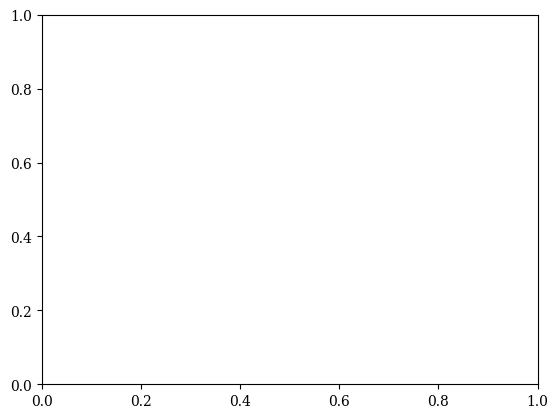

In [89]:




fig, ax = plt.subplots()

ax = layout.axes[('Z3', 'z3')]
sns.kdeplot(x=test_embedding[:, 0], y=test_embedding[:, 1], hue=y_test, levels=3,  thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

legend_labels = []

for i in ['Casting Sim, Unsteady', ]: # plottingdf['class'].unique():

    if "Casting" in plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color, marker='d')
        legend_labels.append(Line2D([0], [0],marker='d', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))
    if "Circling" in plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color)
        legend_labels.append(Line2D([0], [0],marker='.', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))
    

ax.set_xlim(1,13)
ax.set_ylim(7,13)
ax.set_aspect('equal')


#ax.legend( handles=legend_labels)# orange_patch, yellow_patch, blue_patch, cyan_patch,black_patch],)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.axis('off')


layout.append_figure_to_layer(layout.figures['Z3'], 'Z3', cleartarget=True)


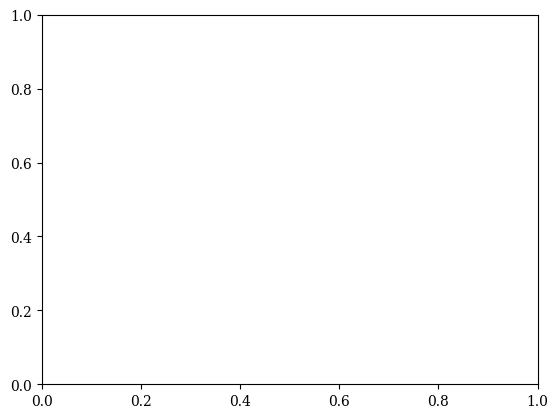

In [90]:




fig, ax = plt.subplots()

ax = layout.axes[('Z2', 'z2')]
sns.kdeplot(x=test_embedding[:, 0], y=test_embedding[:, 1], hue=y_test, levels=3,  thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

legend_labels = []

for i in ['Circling Sim, Steady',  ]: # plottingdf['class'].unique():

    if "Casting" in plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color, marker='d')
        legend_labels.append(Line2D([0], [0],marker='d', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))
    if "Circling" in plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color)
        legend_labels.append(Line2D([0], [0],marker='.', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))
    
    #legend_labels.append(mpatches.Patch(color=plottingdf[plottingdf['class']==i].color.iloc[0], label=plottingdf[plottingdf['class']==i]['dataset_name'].iloc[0]))

    #legend_labels.append(mpatches.Patch(color=plottingdf[plottingdf['class']==i].color.iloc[0], label=plottingdf[plottingdf['class']==i]['dataset_name'].iloc[0]))

    
    
ax.set_xlim(1,13)
ax.set_ylim(7,13)
ax.set_aspect('equal')

#ax.legend( handles=legend_labels)# orange_patch, yellow_patch, blue_patch, cyan_patch,black_patch],)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.axis('off')


layout.append_figure_to_layer(layout.figures['Z2'], 'Z2', cleartarget=True)


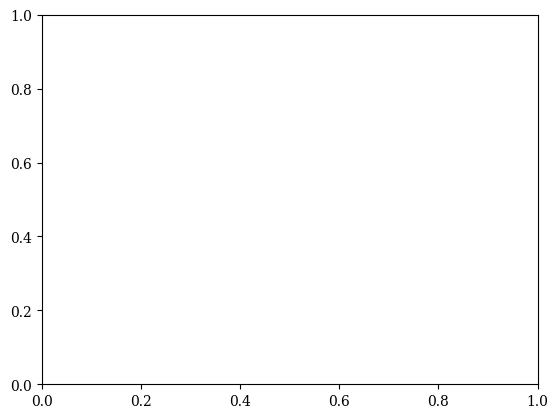

In [91]:




fig, ax = plt.subplots()

ax = layout.axes[('Z4', 'z4')]
sns.kdeplot(x=test_embedding[:, 0], y=test_embedding[:, 1], hue=y_test, levels=3,  thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

legend_labels = []

for i in ['Circling Sim, Unsteady',  ]: # plottingdf['class'].unique():

    if "Casting" in plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color, marker='d')
        legend_labels.append(Line2D([0], [0],marker='d', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))
    if "Circling" in plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]:
        ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color)
        legend_labels.append(Line2D([0], [0],marker='.', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))

    
ax.set_xlim(1,13)
ax.set_ylim(7,13)
ax.set_aspect('equal')


fifi.mpl_functions.set_fontsize(ax, 6)
ax.axis('off')


layout.append_figure_to_layer(layout.figures['Z4'], 'Z4', cleartarget=True)


# Save Figure

In [92]:
layout.write_svg('f6_real_vs_sim.svg')